In [34]:
import pandas as pd
from datetime import date, timedelta
import missingno as msno
import plotly.express as px
import sys

import random
import numpy as np

import sys

sys.path.insert(0, "../../utils")

from plots import *
from string_handling import *
from modules import *

enc = 'utf-8' 

random.seed(0)
np.random.seed(0)

pd.set_option('display.max_columns', None)

In [35]:
REGION = 'ExtNord'
YEARS = range(2014, 2025)

In [36]:
datasets = []

for YEAR in YEARS:
    print(f"Reading data for Cameroon {REGION} in {YEAR}")
    # Load the dataset for the specified year
    datasets.append(pd.read_csv(f'../../data/{REGION}/CM_{REGION}_Dataset_X_{YEAR}.csv', encoding=enc))

# Concatenate all datasets into a single DataFrame
df = pd.concat(datasets, ignore_index=True)

try:
    df.drop(['Unnamed: 0'], axis=1, inplace=True)
except KeyError:
    print("Column 'Unnamed: 0' not found in the DataFrame.")

Reading data for Cameroon ExtNord in 2014
Reading data for Cameroon ExtNord in 2015
Reading data for Cameroon ExtNord in 2016
Reading data for Cameroon ExtNord in 2017
Reading data for Cameroon ExtNord in 2018
Reading data for Cameroon ExtNord in 2019
Reading data for Cameroon ExtNord in 2020
Reading data for Cameroon ExtNord in 2021
Reading data for Cameroon ExtNord in 2022
Reading data for Cameroon ExtNord in 2023
Reading data for Cameroon ExtNord in 2024


In [37]:
print(df.shape)

df.head()

(41844, 51)


,dt_placement,year,month,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,rainfall,rainfall_acc,monthly_rainfall_acc,year_biovars,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2014-01,2014,1,0.5,0.866,extreme nord,diamare,bogo,balaza,14.515776,10.786560,0.229944,-0.106548,-0.406425,0.106548,0.235708,-0.099787,-0.399243,0.099787,0.016117,0.016614,0.012368,0.016614,26.66,36.36,16.79,15.29,41.26,0.0000,0.0000,0.0000,2013,30.50,25.33,61.79,350.32,54.0,13.0,41.0,27.83,30.50,35.67,27.33,1377.0,496.0,0.0,144.44,1114.0,0.0,97.0,914.0
1,2014-01,2014,1,0.5,0.866,extreme nord,diamare,bogo,balda,14.724237,10.914551,0.233327,-0.120509,-0.403203,0.120509,0.237530,-0.110815,-0.396799,0.110815,0.015537,0.013778,0.008671,0.013778,27.25,38.35,16.02,13.94,42.84,0.0000,0.0000,0.0000,2013,31.08,25.17,59.92,398.77,55.0,13.0,42.0,27.33,31.17,36.83,27.33,1303.0,489.0,0.0,149.02,1078.0,0.0,66.0,1078.0
2,2014-01,2014,1,0.5,0.866,extreme nord,diamare,bogo,bogo,14.597860,10.743440,0.216790,-0.091465,-0.385743,0.091465,0.225764,-0.079123,-0.382786,0.079123,0.010775,0.008443,0.008236,0.008443,27.04,37.23,16.92,15.70,41.54,0.0001,0.0025,0.0025,2013,30.12,26.42,64.43,303.11,53.0,12.0,41.0,27.67,29.83,33.83,27.50,1359.0,489.0,0.0,146.88,1124.0,0.0,89.0,891.0
3,2014-01,2014,1,0.5,0.866,extreme nord,diamare,bogo,borai,14.606980,10.653607,0.244099,-0.098628,-0.399229,0.098628,0.239033,-0.091542,-0.394136,0.091542,0.011823,0.010843,0.011842,0.010843,26.08,34.95,17.07,15.13,40.66,0.0001,0.0017,0.0017,2013,30.33,24.83,62.08,316.47,53.0,13.0,40.0,27.83,30.33,35.00,27.83,1451.0,512.0,0.0,144.81,1188.0,0.0,92.0,1188.0
4,2014-01,2014,1,0.5,0.866,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,0.238072,-0.091182,-0.404626,0.091182,0.238932,-0.088755,-0.400715,0.088755,0.022838,0.020541,0.012782,0.020541,27.04,37.18,16.80,14.97,41.79,0.0002,0.0062,0.0062,2013,30.58,26.17,59.47,332.92,55.0,11.0,44.0,28.17,31.00,35.00,28.00,1343.0,481.0,0.0,145.68,1106.0,1.0,93.0,911.0


Text(0.5, 1.0, 'Years: 2014 - 2024')

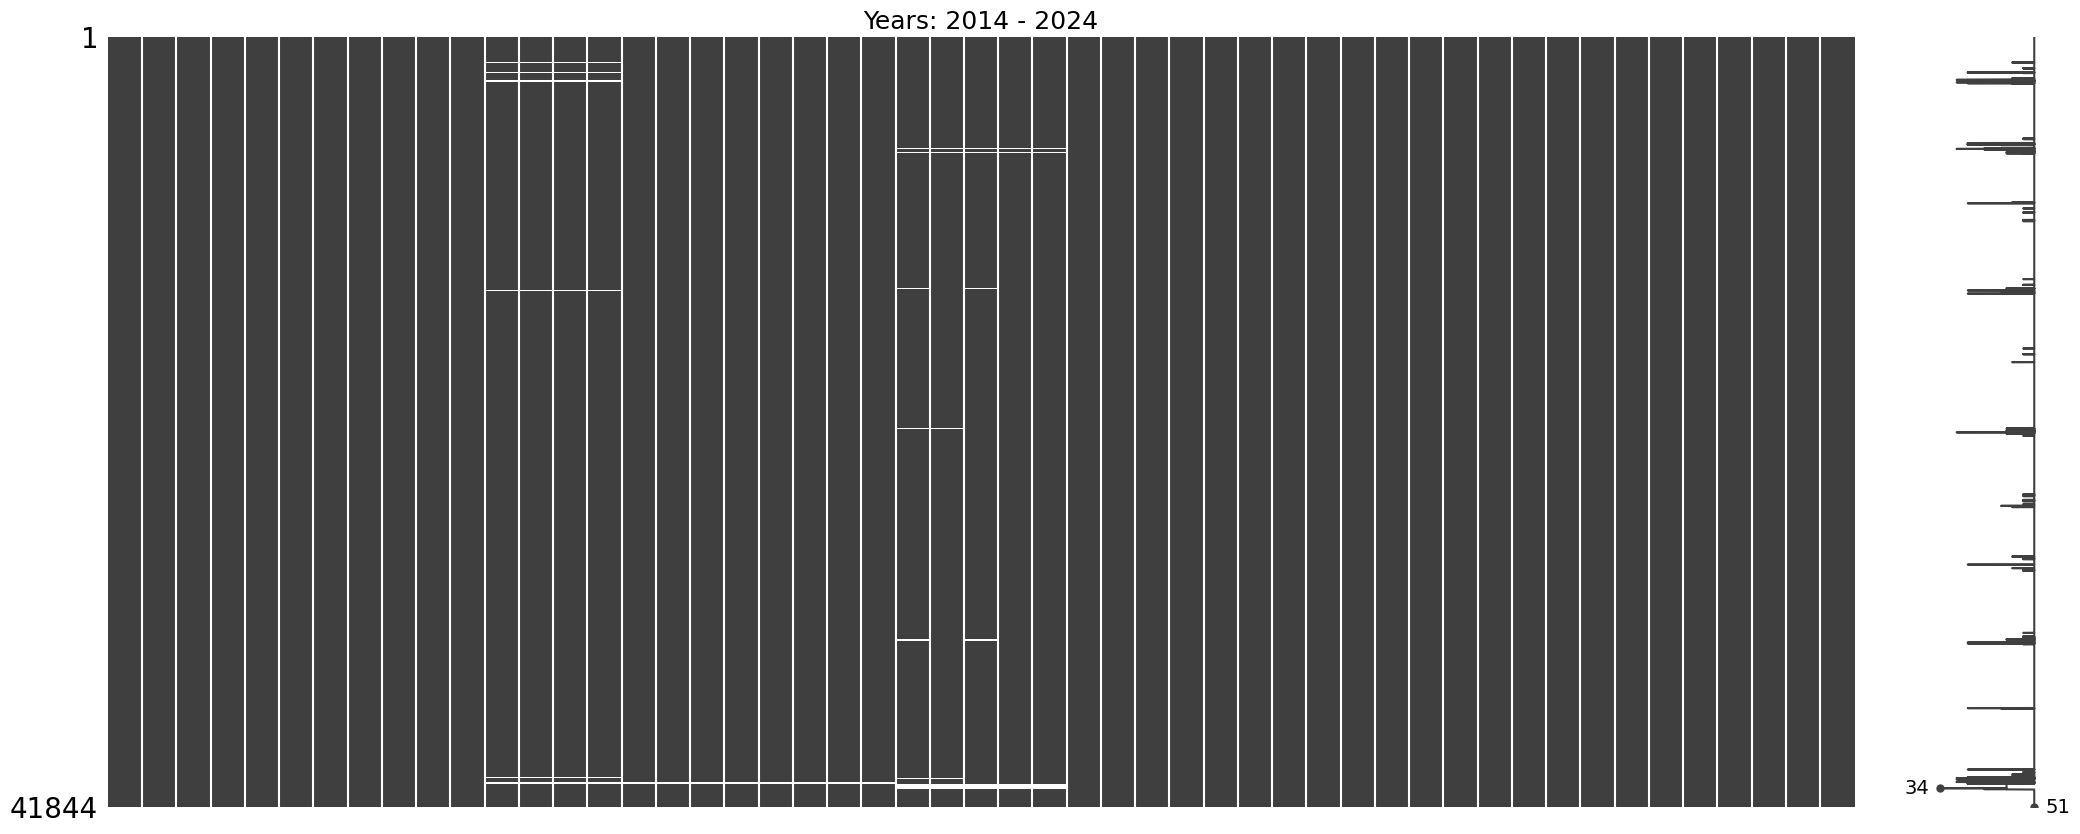

In [38]:
msno.matrix(df, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Years: {min(YEARS)} - {max(YEARS)}", fontsize=18)

In [39]:
cases_df = pd.read_csv(f'../../data/CM_MAL_cases_GID2_2015-2024_fixed.csv', encoding=enc)

try:
    cases_df.drop(['Unnamed: 0'], axis=1, inplace=True)
except KeyError:
    print("Column 'Unnamed: 0' not found in the DataFrame.")

In [40]:
print(cases_df.shape)

cases_df.head()

(75104, 23)


,GID0,GID2,GID3,Facility,Year,Month,dt_placement,Case_UND5,Case_OVR5,Case_PRGN,Case_TOTAL,Sevr_UND5,Sevr_OVR5,Sevr_PRGN,Sevr_TOTAL,Hosp_UND5,Hosp_OVR5,Hosp_PRGN,Hosp_TOTAL,Death_UND5,Death_OVR5,Death_PRGN,Death_TOTAL
0,extreme nord,bogo,balaza,csi balaza alcali,2015,1,01-2015,49.0,43.0,2.0,94.0,3.0,12.0,2.0,17.0,3.0,12.0,2.0,17.0,0.0,0.0,0.0,0.0
1,extreme nord,bogo,balda,csi balda,2015,1,01-2015,2.0,5.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,extreme nord,bogo,bogo,csi bogo,2015,1,01-2015,19.0,53.0,0.0,72.0,17.0,51.0,0.0,68.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,extreme nord,bogo,bogo,hd bogo,2015,1,01-2015,6.0,10.0,3.0,19.0,5.0,7.0,3.0,15.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,extreme nord,bogo,borai,csi borai,2015,1,01-2015,16.0,14.0,1.0,31.0,4.0,3.0,1.0,8.0,4.0,3.0,1.0,8.0,0.0,0.0,0.0,0.0


In [41]:
cases_df = cases_df[cases_df['GID0'] == 'extreme nord'].copy()

In [42]:
cases_df.drop(columns=[col for col in cases_df.columns if 'Death' in col], axis=1, inplace=True)
cases_df.drop(columns=['Facility'], axis=1, inplace=True)
cases_df = cases_df.astype({col: 'Int64' for col in cases_df.select_dtypes(include='float').columns})
cases_df.columns = [col if i < 3 else col.lower() for i, col in enumerate(cases_df.columns)]

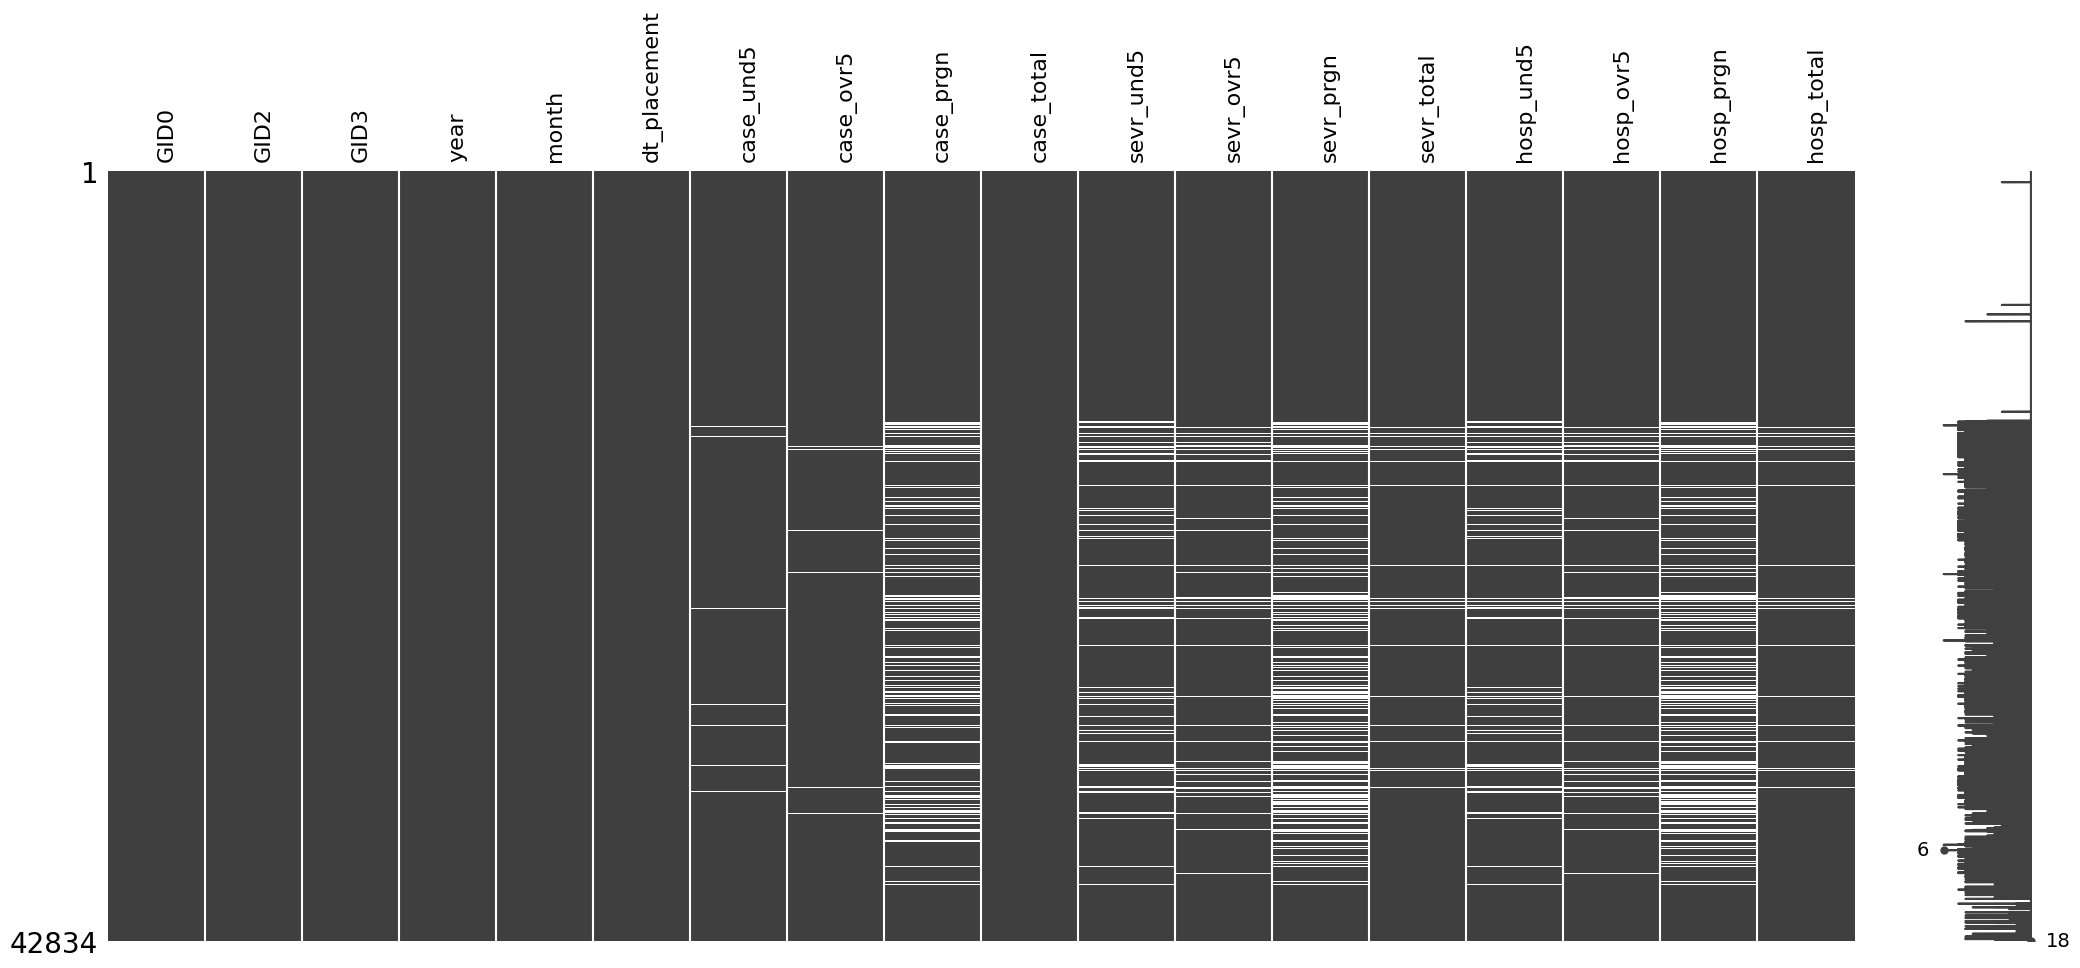

In [43]:
msno.matrix(cases_df, label_rotation=90)
ax = plt.gca()

In [44]:
cases_df.head()

,GID0,GID2,GID3,year,month,dt_placement,case_und5,case_ovr5,case_prgn,case_total,sevr_und5,sevr_ovr5,sevr_prgn,sevr_total,hosp_und5,hosp_ovr5,hosp_prgn,hosp_total
0,extreme nord,bogo,balaza,2015,1,01-2015,49,43,2,94,3,12,2,17,3,12,2,17
1,extreme nord,bogo,balda,2015,1,01-2015,2,5,0,7,0,0,0,0,0,0,0,0
2,extreme nord,bogo,bogo,2015,1,01-2015,19,53,0,72,17,51,0,68,0,0,0,0
3,extreme nord,bogo,bogo,2015,1,01-2015,6,10,3,19,5,7,3,15,1,0,0,1
4,extreme nord,bogo,borai,2015,1,01-2015,16,14,1,31,4,3,1,8,4,3,1,8


In [45]:
df['location'] = list(zip(df['GID0'], df['GID2'], df['GID3']))
cases_df['location'] = list(zip(cases_df['GID0'], cases_df['GID2'], cases_df['GID3']))

In [51]:
all_locations_df = set(df['location'])
all_locations_df_cases = set(cases_df['location'])

all_exist = all_locations_df_cases.issubset(all_locations_df)
print("All locations from frame2 (cases) exist in frame1 (input):", all_exist)

missing_locations = all_locations_df_cases - all_locations_df
sorted(missing_locations)

All locations from frame2 (cases) exist in frame1 (input): False


[('extreme nord', 'guere', 'madiako'),
 ('extreme nord', 'kousseri', 'dargala'),
 ('extreme nord', 'kousseri', 'houla'),
 ('extreme nord', 'kousseri', 'zileng'),
 ('extreme nord', 'maroua 3', 'moutourwa'),
 ('extreme nord', 'meri', 'douroum'),
 ('extreme nord', 'mokolo', 'douvangar'),
 ('extreme nord', 'moutourwa', 'foulou'),
 ('extreme nord', 'tokombere', 'ndoukoula'),
 ('extreme nord', 'tokombere', 'ouro tchede')]